# GISLR — why the models stop at ~75%

**Standalone diagnostic** (not a pipeline stage): it reads the run registry and writes only to
`data/cache/gislr/plateau/` and `docs/`. Nothing here changes a run record.

## The question, stated so it can be wrong

> *Are semantically similar signs (`awake`/`wake`, `lips`/`mouth`, `pen`/`pencil`) the reason
> accuracy stops at ~75%?*

The existing evidence (TODO §7.1) established that the **most-confused pairs are semantic
near-synonyms**, and that they replicate across architectures and feature pipelines. That is a
statement about *where the errors are*, not about *how many* there are — and the second is what
a ceiling claim needs. Even a model with a totally unrelated weakness would have its residual
errors land somewhere, and near-synonyms are the obvious somewhere.

So the hypothesis is tested as a **quantity**, not a vibe:

| | measurement | refutes the hypothesis if |
|---|---|---|
| §4 | error mass absorbed by confusable pairs, vs a random-pair control | the share is small — the plateau is then mostly elsewhere |
| §5 | top-k recovery, split by semantic vs other errors | other errors are *not* near-misses — a different failure |
| §7 | does the model confuse these pairs on the **train** split too? | train confusion ≈ 0 → generalization, not a label ceiling |
| §8 | can a dedicated binary classifier separate one pair? | ~95% → the signal is there, the 250-way head is not using it |

**Two facts already on record that constrain the answer.** Train accuracy is 90–99% against
val ~75% (gap 0.16–0.24, `docs/logs/daily/2026-07-19.md`), so the network *can* separate these
classes on examples it has seen. And the canonical val set holds only 30–41 videos per class,
with `corr(n_val, accuracy) = 0.35` — imbalance is a minor effect, not the cause.

## Artifacts

| path | what |
|---|---|
| `data/cache/gislr/plateau/confusion_aggregate.npy` | mean row-normalised confusion over canonical runs |
| `data/cache/gislr/plateau/pairs.csv` | symmetric confusable pairs, ranked |
| `data/cache/gislr/plateau/oracle_curve.csv` | §4 — accuracy vs number of pairs solved, with control |
| `data/cache/gislr/plateau/topk_recovery.csv` | §5 — near-miss rates by error type |
| `data/cache/gislr/plateau/train_confusion.csv` | §7 — train-split confusion on the same pairs (GPU) |
| `data/cache/gislr/plateau/pair_probes.csv` | §8 — per-pair binary separability (GPU) |
| `docs/reports/plateau-diagnosis.md` | the write-up you produce from §9 |

**Resumability.** Every cell writes its artifact and skips if it exists (`FORCE = True` to
recompute). §2 and §7 are the slow ones; §7 is manifest-driven per run.

**GPU.** §2–§6 are pure numpy over committed artifacts — no GPU, ~1 minute. §7 and §8 need
CUDA and are the ones to hand to a machine that has it.


## 1. Setup

Reads the registry directly, so it does not depend on `index.csv` being fresh.

In [1]:
# =====
# Setup: imports, tunables, resolved paths
# =====
import json
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import display

from sb.core.paths import CACHE_DIR, MODELS_DIR, gislr_dir
from sb.core.vocab import invert, load_label_map

MIN_ACC = 0.70        # only runs in the plateaued family; excludes cnn1d (~0.54)
N_PAIRS_HEADLINE = 20 # pairs treated as "the semantic cluster set" in §4-§7
N_CONTROL_DRAWS = 10  # random-pair control repeats
SEED = 42
FORCE = False         # True = recompute every cached artifact

OUT = CACHE_DIR / "gislr" / "plateau"
OUT.mkdir(parents=True, exist_ok=True)
DATA_DIR = gislr_dir()
SIGN2IDX = load_label_map(DATA_DIR)
IDX2SIGN = invert(SIGN2IDX)
N_CLASSES = len(SIGN2IDX)
rng = np.random.default_rng(SEED)

print(f"registry : {MODELS_DIR}")
print(f"cache    : {OUT}")
print(f"classes  : {N_CLASSES}")

registry : C:\Users\user2\sign2speech\registry\runs
cache    : C:\Users\user2\sign2speech\data\cache\gislr\plateau
classes  : 250


## 2. The runs this diagnosis speaks for

A canonical eval and a stored prediction vector are both required — without them a run cannot
contribute a confusion matrix. `MIN_ACC` keeps the *plateaued family*: including `cnn1d` at
~0.54 would drag every aggregate toward a model that has a different problem entirely.

In [2]:
# =====
# Load canonical runs (labels, preds, top-k when present)
# =====
def load_runs(min_acc=MIN_ACC):
    """One row per canonical run with its stored val predictions."""
    out = []
    for meta_path in sorted(MODELS_DIR.glob("*/meta.json")):
        meta = json.loads(meta_path.read_text(encoding="utf-8"))
        npz = meta_path.parent / "assets" / "val_predictions.npz"
        acc = meta["metrics"].get("overall_accuracy")
        if meta["metrics"].get("eval_status") != "canonical" or not npz.is_file():
            continue
        if acc is None or acc < min_acc:
            continue
        d = np.load(npz)
        out.append({
            "run_id": meta["run_id"], "architecture": meta["architecture"],
            "subset": meta["subset"], "coords": meta["coords"], "accuracy": acc,
            "labels": d["labels"].astype(int), "preds": d["preds"].astype(int),
            # runs evaluated before 2026-09-04 have no top-k; re-run sb-evaluate to backfill
            "topk": d["topk_idx"].astype(int) if "topk_idx" in d.files else None,
        })
    return out


RUNS = load_runs()
summary = pd.DataFrame([{k: r[k] for k in
                         ("run_id", "architecture", "subset", "coords", "accuracy")}
                        | {"has_topk": r["topk"] is not None} for r in RUNS])
print(f"{len(RUNS)} runs at accuracy >= {MIN_ACC} · mean {summary.accuracy.mean():.4f}")
print(f"{summary.has_topk.sum()} of them have top-k stored (needed by §5)")
display(summary.sort_values("accuracy", ascending=False).head(10))

31 runs at accuracy >= 0.7 · mean 0.7433
1 of them have top-k stored (needed by §5)


,run_id,architecture,subset,coords,accuracy,has_topk
15,1784447175,bilstm,ME_126,xy,0.756880,False
16,1784447187,gru,ME_126,xy,0.756456,False
22,1784453891,gru,ME_126,xy,0.756456,True
11,1784397301,bilstm,FP_118,xy,0.752540,False
20,1784451456,gru,FP_118,xy,0.750529,False
24,1784455294,gru,FP_118,xy,0.750529,False
9,1784395799,bilstm,ME_126,xy,0.750423,False
18,1784449770,gru,ME_132,xy,0.749259,False
23,1784454580,gru,ME_132,xy,0.749259,False
28,1784459026,bilstm,ME_132,xy,0.747566,False


## 3. Aggregate confusion and the confusable pairs

Each run's confusion matrix is **row-normalised before averaging**, so a class with more val
examples does not dominate, and every run contributes equally regardless of its accuracy.

Pairs are scored **symmetrically** (`C[i,j] + C[j,i]`). A one-directional confusion is usually
a weak class collapsing into a strong neighbour; a symmetric one is the signature of two
classes that genuinely overlap — which is what the hypothesis is about.

In [3]:
# =====
# Aggregate confusion over runs -> ranked symmetric pairs
# (tunable: FORCE to recompute)
# =====
conf_path, pairs_path = OUT / "confusion_aggregate.npy", OUT / "pairs.csv"

if FORCE or not conf_path.exists():
    C = np.zeros((N_CLASSES, N_CLASSES))
    for r in RUNS:
        M = np.zeros((N_CLASSES, N_CLASSES))
        np.add.at(M, (r["labels"], r["preds"]), 1)
        C += M / np.maximum(M.sum(axis=1, keepdims=True), 1)   # row-normalise, then average
    C /= len(RUNS)
    np.fill_diagonal(C, 0.0)
    np.save(conf_path, C)
else:
    C = np.load(conf_path)

sym = C + C.T
iu = np.triu_indices(N_CLASSES, 1)
rank = np.argsort(-sym[iu])
pairs_df = pd.DataFrame({
    "a": [IDX2SIGN[int(iu[0][k])] for k in rank],
    "b": [IDX2SIGN[int(iu[1][k])] for k in rank],
    "a_idx": [int(iu[0][k]) for k in rank],
    "b_idx": [int(iu[1][k]) for k in rank],
    "symmetric_rate": [float(sym[iu[0][k], iu[1][k]]) for k in rank],
    "a_to_b": [float(C[iu[0][k], iu[1][k]]) for k in rank],
    "b_to_a": [float(C[iu[1][k], iu[0][k]]) for k in rank],
})
pairs_df.to_csv(pairs_path, index=False)
print(f"wrote {pairs_path} ({len(pairs_df)} pairs)")
display(pairs_df.head(20)[["a", "b", "symmetric_rate", "a_to_b", "b_to_a"]])

wrote C:\Users\user2\sign2speech\data\cache\gislr\plateau\pairs.csv (31125 pairs)


,a,b,symmetric_rate,a_to_b,b_to_a
0,awake,wake,0.838710,0.416129,0.422581
1,lips,mouth,0.533023,0.212097,0.320926
2,hear,listen,0.411075,0.200629,0.210445
3,pen,pencil,0.403536,0.165323,0.238213
4,gift,give,0.366726,0.065343,0.301382
5,cut,scissors,0.356582,0.236269,0.120314
6,finger,wait,0.342518,0.154499,0.188018
7,stay,that,0.336163,0.135823,0.200340
8,duck,goose,0.329601,0.088906,0.240695
9,animal,have,0.283139,0.179724,0.103416


## 4. How much of the error is actually semantic? — the headline measurement

Merge the top-`N` confusable pairs into single classes and re-score: that is the accuracy the
models would reach **if the semantic confusions were solved perfectly**. It is an upper bound,
not a prediction.

**The random-pair control is what makes the number mean anything.** Merging any `N` pairs can
only raise accuracy, so the semantic number alone is uninterpretable — the question is how much
it beats merging `N` pairs chosen at random. One merge map is built and applied to *both* sides
of the comparison; building two would let a label and a prediction land in different clusters
and produce an accuracy *below* baseline, which is impossible for a merge.

baseline 0.7433
top-20 pairs absorb 10.5% of all errors


,n_pairs,semantic,control_mean,gain_over_control
0,5,0.753991,0.743365,0.010626
1,10,0.760475,0.743461,0.017014
2,20,0.770414,0.743504,0.026910
3,30,0.776788,0.743586,0.033203
4,50,0.787335,0.743843,0.043492
5,75,0.796554,0.744540,0.052013


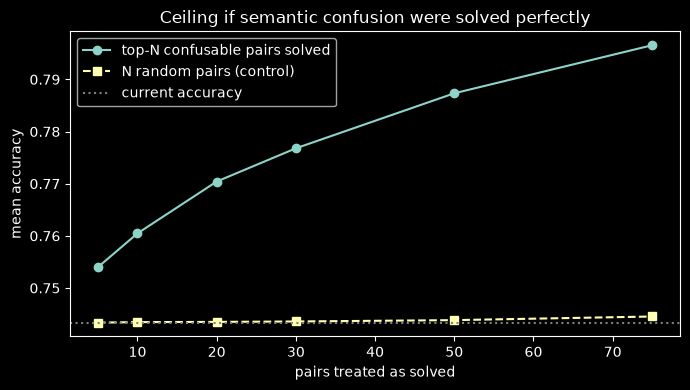

In [4]:
# =====
# Oracle ceiling: solve the top-N semantic pairs, vs a random-pair control
# (tunables: N_GRID, N_CONTROL_DRAWS)
# =====
N_GRID = [5, 10, 20, 30, 50, 75]

curve_path = OUT / "oracle_curve.csv"


def merge_map(selected_pairs):
    """class index -> cluster id, union-find over the given pairs."""
    parent = list(range(N_CLASSES))

    def find(x):
        while parent[x] != x:
            parent[x] = parent[parent[x]]
            x = parent[x]
        return x

    for i, j in selected_pairs:
        a, b = find(int(i)), find(int(j))
        if a != b:
            parent[a] = b
    return np.array([find(c) for c in range(N_CLASSES)])


def oracle_accuracy(selected_pairs, runs=None):
    """Mean accuracy over runs when the given pairs count as one class."""
    mm = merge_map(selected_pairs)
    return float(np.mean([(mm[r["labels"]] == mm[r["preds"]]).mean()
                          for r in (runs or RUNS)]))


if FORCE or not curve_path.exists():
    ranked = list(zip(pairs_df.a_idx, pairs_df.b_idx))
    baseline = oracle_accuracy([])
    rows = []
    for n in N_GRID:
        controls = [oracle_accuracy([(int(a), int(b))
                                     for a, b in rng.choice(N_CLASSES, size=(n, 2))
                                     if a != b])
                    for _ in range(N_CONTROL_DRAWS)]
        rows.append({"n_pairs": n,
                     "semantic": oracle_accuracy(ranked[:n]),
                     "control_mean": float(np.mean(controls)),
                     "control_std": float(np.std(controls)),
                     "baseline": baseline})
    curve = pd.DataFrame(rows)
    curve["gain_over_control"] = curve.semantic - curve.control_mean
    curve.to_csv(curve_path, index=False)
else:
    curve = pd.read_csv(curve_path)

# what share of the errors do the headline pairs absorb?
mm = merge_map(list(zip(pairs_df.a_idx, pairs_df.b_idx))[:N_PAIRS_HEADLINE])
tot = sem = 0
for r in RUNS:
    e = r["labels"] != r["preds"]
    tot += int(e.sum())
    sem += int(((mm[r["labels"]] == mm[r["preds"]]) & e).sum())

print(f"baseline {curve.baseline.iloc[0]:.4f}")
print(f"top-{N_PAIRS_HEADLINE} pairs absorb {sem / tot:.1%} of all errors")
display(curve[["n_pairs", "semantic", "control_mean", "gain_over_control"]])

fig, ax = plt.subplots(figsize=(7, 4))
ax.plot(curve.n_pairs, curve.semantic, "o-", label="top-N confusable pairs solved")
ax.plot(curve.n_pairs, curve.control_mean, "s--", label="N random pairs (control)")
ax.axhline(curve.baseline.iloc[0], color="grey", ls=":", label="current accuracy")
ax.set_xlabel("pairs treated as solved"); ax.set_ylabel("mean accuracy")
ax.set_title("Ceiling if semantic confusion were solved perfectly")
ax.legend(); fig.tight_layout()
fig.savefig(OUT / "oracle_curve.png", dpi=110)
plt.show()

## 5. Are the wrong answers near-misses?

If the true label sits at rank 2, the model *has* the information and is losing a close
decision — which a rescoring layer (TODO §8) could recover. If the true label is nowhere in
the top 5, the features do not carry it and no amount of re-ranking helps.

Split by error type, this separates "the semantic pairs are a decision problem" from "the rest
of the error is a representation problem". Needs `topk_idx`, added to the eval on 2026-09-04 —
re-run `sb-evaluate` on a run to backfill it.

In [5]:
# =====
# Top-k recovery, split by semantic vs other errors
# =====
topk_path = OUT / "topk_recovery.csv"
have = [r for r in RUNS if r["topk"] is not None]

if not have:
    print("No run has top-k stored yet. Backfill with:\n"
          "  sb-evaluate registry/runs/<run_id>\n"
          "then re-run this cell.")
else:
    mm = merge_map(list(zip(pairs_df.a_idx, pairs_df.b_idx))[:N_PAIRS_HEADLINE])
    rows = []
    for r in have:
        lab, pred, tk = r["labels"], r["preds"], r["topk"]
        err = lab != pred
        is_sem = err & (mm[lab] == mm[pred])
        for name, mask in (("semantic", is_sem), ("other", err & ~is_sem)):
            if not mask.sum():
                continue
            rows.append({
                "run_id": r["run_id"], "architecture": r["architecture"],
                "error_type": name, "n_errors": int(mask.sum()),
                "recovered_at_2": float((tk[mask][:, :2] == lab[mask][:, None]).any(1).mean()),
                "recovered_at_5": float((tk[mask] == lab[mask][:, None]).any(1).mean()),
            })
    topk = pd.DataFrame(rows)
    topk.to_csv(topk_path, index=False)
    display(topk.groupby("error_type")[["n_errors", "recovered_at_2", "recovered_at_5"]].mean())
    print(f"\nwrote {topk_path} ({len(have)} run(s))")

,n_errors,recovered_at_2,recovered_at_5
error_type,,,
other,2078.0,0.310876,0.557748
semantic,223.0,0.766816,0.946188



wrote C:\Users\user2\sign2speech\data\cache\gislr\plateau\topk_recovery.csv (1 run(s))


## 6. Ruling out the boring explanations

Before blaming semantics, check the two cheaper stories: **class imbalance** (rare classes are
the missed ones) and **a few catastrophic classes** (the error is concentrated in a handful of
labels rather than spread).

corr(support, accuracy) = +0.338   (support spans 30-42 videos/class)
the 10 worst classes carry 8.6% of all error; the worst 50 carry 33.8%
a uniform spread would put 10/250 = 4.0% and 50/250 = 20.0% there


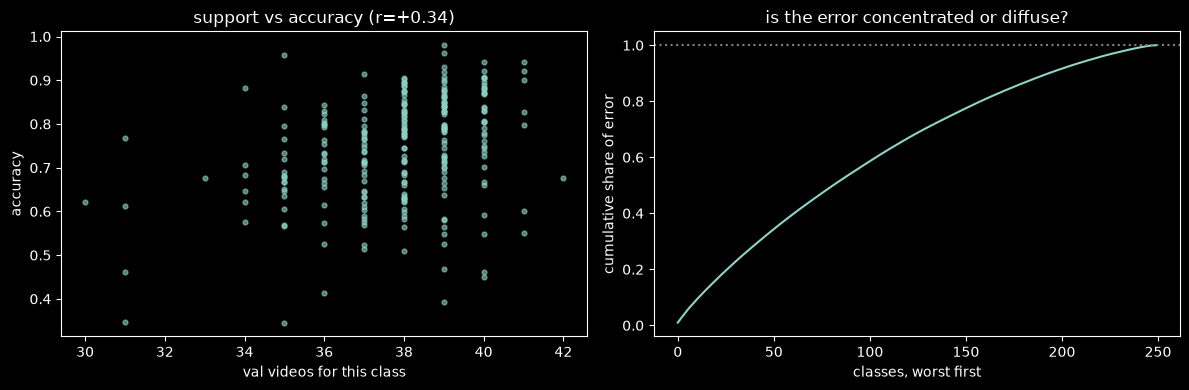

In [6]:
# =====
# Per-class accuracy vs support, and the error concentration curve
# =====
per_class = np.zeros((N_CLASSES, 2))  # [correct, total]
for r in RUNS:
    np.add.at(per_class[:, 1], r["labels"], 1)
    np.add.at(per_class[:, 0], r["labels"][r["labels"] == r["preds"]], 1)
acc = per_class[:, 0] / np.maximum(per_class[:, 1], 1)
support = per_class[:, 1] / len(RUNS)

corr = float(np.corrcoef(support, acc)[0, 1])
err_share = np.sort((1 - acc) * support)[::-1]
err_share = err_share / err_share.sum()
top10 = err_share[:10].sum()
top50 = err_share[:50].sum()
print(f"corr(support, accuracy) = {corr:+.3f}   "
      f"(support spans {support.min():.0f}-{support.max():.0f} videos/class)")
print(f"the 10 worst classes carry {top10:.1%} of all error; the worst 50 carry {top50:.1%}")
print(f"a uniform spread would put 10/250 = 4.0% and 50/250 = 20.0% there")

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].scatter(support, acc, s=12, alpha=0.6)
axes[0].set_xlabel("val videos for this class"); axes[0].set_ylabel("accuracy")
axes[0].set_title(f"support vs accuracy (r={corr:+.2f})")
axes[1].plot(np.cumsum(err_share))
axes[1].axhline(1.0, color="grey", ls=":")
axes[1].set_xlabel("classes, worst first"); axes[1].set_ylabel("cumulative share of error")
axes[1].set_title("is the error concentrated or diffuse?")
fig.tight_layout(); fig.savefig(OUT / "error_concentration.png", dpi=110); plt.show()

## 7. The generalization test — does it confuse these pairs on **training** data? *(GPU)*

This is the measurement that separates the two readings of §7.1, which are currently in
tension: the 07-19 verdict was **overfitting** (train 90–99% vs val ~75%), while the 08-23 note
leaned **label ceiling**. Both cannot be the main story.

- **train confusion ≈ 0, val confusion high** → the pair is separable and the model separates
  it on seen data. It is a *generalization* failure: §7.4 augmentation, more data, regularization.
- **train confusion also high** → the model cannot separate them even by memorising. That is a
  genuine representation or label ceiling, and §7.2/§7.3 features are the lever.

Runs inference over a sample of the **train** split. Sampling is per-class and seeded, so this
is a few minutes rather than an hour; raise `TRAIN_SAMPLE_PER_CLASS` for a tighter estimate.

In [7]:
# =====
# Train-split confusion on the same pairs (GPU; tunables: RUN_ID, TRAIN_SAMPLE_PER_CLASS)
# Skip-if-done -- delete the csv to recompute.
# =====
RUN_ID = None                  # None = the best streaming run in RUNS
TRAIN_SAMPLE_PER_CLASS = 8     # val has 30-41/class; 8 x 250 = 2000 clips is plenty for a rate

train_conf_path = OUT / "train_confusion.csv"

if train_conf_path.exists() and not FORCE:
    display(pd.read_csv(train_conf_path).head(20))
else:
    import torch
    from tqdm.auto import tqdm

    from sb.mlops.artifacts import ensure_local
    from sb.recognize.architectures import build_model
    from sb.recognize.data import get_canonical_split
    from sb.recognize.evaluate import load_video, load_video_firstplace

    streaming = [r for r in RUNS if r["architecture"] != "bilstm"]
    chosen = (max(streaming, key=lambda r: r["accuracy"]) if RUN_ID is None
              else next(r for r in RUNS if r["run_id"] == RUN_ID))
    run_dir = MODELS_DIR / str(chosen["run_id"])
    print(f"run {chosen['run_id']} · {chosen['architecture']}/{chosen['subset']}/"
          f"{chosen['coords']} · val {chosen['accuracy']:.4f}")

    ckpt = torch.load(ensure_local(run_dir, "best.pt"), map_location="cuda",
                      weights_only=False)
    landmarks = np.asarray(ckpt["landmarks"]) if ckpt.get("landmarks") is not None else None
    model = build_model(ckpt.get("arch", "gru"), ckpt["feature_dim"],
                        N_CLASSES, ckpt["hyp"]).cuda()
    model.load_state_dict(ckpt["model_state"])
    model.eval()

    train_split, _ = get_canonical_split(DATA_DIR, SIGN2IDX)
    # GroupBy.sample, not groupby().apply(): the latter's handling of the
    # grouping column changed in pandas 3 and this only needs a stratified draw
    sample = train_split.groupby("label", group_keys=False).sample(
        n=TRAIN_SAMPLE_PER_CLASS, random_state=SEED)
    coords = ckpt.get("coords", "xyz")
    is_fp = ckpt.get("features") == "firstplace"
    max_len = ckpt["hyp"].get("max_seq_len", 384)
    diff_mode = ckpt.get("diff_mode", "forward")

    preds = np.zeros(len(sample), dtype=int)
    labels = sample["label"].to_numpy()
    bar = tqdm(total=len(sample), desc=f"train inference · run {chosen['run_id']}",
               dynamic_ncols=True)
    with torch.no_grad():
        for b0 in range(0, len(sample), 128):
            rows = sample.iloc[b0:b0 + 128]
            loaded = [load_video_firstplace(DATA_DIR / p, landmarks, coords,
                                            max_len, diff_mode) if is_fp
                      else load_video(DATA_DIR / p, landmarks, coords)
                      for p in rows["path"]]
            order = np.argsort([-t for _, t in loaded])
            lengths = torch.tensor([loaded[i][1] for i in order])
            padded = torch.zeros(len(loaded), int(lengths[0]), loaded[0][0].shape[1])
            for j, i in enumerate(order):
                padded[j, : loaded[i][1]] = torch.from_numpy(loaded[i][0])
            out = model(padded.cuda(), lengths).argmax(-1).cpu().numpy()
            inv = np.empty_like(order); inv[order] = np.arange(len(order))
            preds[b0:b0 + len(rows)] = out[inv]
            bar.update(len(rows))
            bar.set_postfix_str(f"acc {np.mean(preds[:b0 + len(rows)] == labels[:b0 + len(rows)]):.3f}")
    bar.close()

    # per-pair: how often does the pair get confused on TRAIN vs on VAL?
    val_lab, val_pred = chosen["labels"], chosen["preds"]
    rows = []
    for _, p in pairs_df.head(N_PAIRS_HEADLINE).iterrows():
        i, j = int(p.a_idx), int(p.b_idx)

        def rate(lab, pred, src, dst):
            m = lab == src
            return float((pred[m] == dst).mean()) if m.sum() else float("nan")

        rows.append({
            "a": p.a, "b": p.b,
            "val_a_to_b": rate(val_lab, val_pred, i, j),
            "val_b_to_a": rate(val_lab, val_pred, j, i),
            "train_a_to_b": rate(labels, preds, i, j),
            "train_b_to_a": rate(labels, preds, j, i),
        })
    tc = pd.DataFrame(rows)
    tc["val_symmetric"] = tc.val_a_to_b + tc.val_b_to_a
    tc["train_symmetric"] = tc.train_a_to_b + tc.train_b_to_a
    tc.insert(0, "run_id", chosen["run_id"])
    tc.to_csv(train_conf_path, index=False)
    print(f"\ntrain accuracy on the sample: {(preds == labels).mean():.4f}")
    print(f"mean symmetric confusion — val {tc.val_symmetric.mean():.3f} · "
          f"train {tc.train_symmetric.mean():.3f}")
    display(tc)

run 1784447187 · gru/ME_126/xy · val 0.7565
Kaggle credentials successfully validated.
fetching 1784447187/best.pt from bracu23101281/signbridge-gislr/pyTorch/gru-me126-xy/2/best.pt …


100%|██████████| 9.77M/9.77M [00:02<00:00, 3.49MB/s]

  1784447187/best.pt restored (10.2 MB, sha256 verified)


train inference · run 1784447187:   0%|          | 0/2000 [00:00<?, ?it/s]


train accuracy on the sample: 0.9635
mean symmetric confusion — val 0.273 · train 0.013


,run_id,a,b,val_a_to_b,val_b_to_a,train_a_to_b,train_b_to_a,val_symmetric,train_symmetric
0,1784447187,awake,wake,0.375000,0.425000,0.25,0.0,0.800000,0.25
1,1784447187,lips,mouth,0.150000,0.256410,0.00,0.0,0.406410,0.00
2,1784447187,hear,listen,0.195122,0.238095,0.00,0.0,0.433217,0.00
3,1784447187,pen,pencil,0.225000,0.179487,0.00,0.0,0.404487,0.00
4,1784447187,gift,give,0.102564,0.228571,0.00,0.0,0.331136,0.00
5,1784447187,cut,scissors,0.162162,0.081081,0.00,0.0,0.243243,0.00
6,1784447187,finger,wait,0.131579,0.142857,0.00,0.0,0.274436,0.00
7,1784447187,stay,that,0.105263,0.105263,0.00,0.0,0.210526,0.00
8,1784447187,duck,goose,0.097561,0.205128,0.00,0.0,0.302689,0.00
9,1784447187,animal,have,0.114286,0.088235,0.00,0.0,0.202521,0.00


## 8. Is the pair separable at all? — a dedicated binary probe *(GPU)*

A 250-way head has to spend capacity everywhere. A classifier that only ever sees `awake` and
`wake` has no such constraint, so its accuracy is close to the **information content of the
landmarks for that distinction**.

- probe ≈ 95% → the signal is there and the 250-way model is failing to use it. Not a label
  ceiling; a capacity/objective problem, and worth a targeted fix.
- probe ≈ 55–65% → the two signs really are near-identical in these landmarks. That *is* a
  ceiling, and the only levers are richer features (handshape resolution) or accepting it.

Deliberately small and fast: a logistic regression on time-pooled features, not another GRU.
Read the result for what it is — **a bound on pooled static geometry, not on the landmarks**.
A high score proves the information is there and the 250-way head is not using it. A low score
proves only that *pooling over time* destroys whatever separates them, which §8b then follows
up on.

In [8]:
# =====
# Per-pair separability probes (GPU-optional; tunables: PROBE_PAIRS, PROBE_C)
# Skip-if-done -- delete the csv to recompute.
# =====
PROBE_PAIRS = 10      # how many of the top pairs to probe
PROBE_C = 1.0         # logistic-regression regularisation

probe_path = OUT / "pair_probes.csv"

if probe_path.exists() and not FORCE:
    display(pd.read_csv(probe_path))
else:
    from sklearn.linear_model import LogisticRegression
    from sklearn.model_selection import cross_val_score
    from tqdm.auto import tqdm

    from sb.core.subsets import get_subset
    from sb.recognize.data import get_canonical_split
    from sb.recognize.features.base_v1 import load_video

    subset = get_subset("ME_126")     # the leaderboard subset
    train_split, val_split = get_canonical_split(DATA_DIR, SIGN2IDX)
    full = pd.concat([train_split, val_split])

    def pooled(path):
        """Mean/std/min/max pooling over time -> one fixed-length vector."""
        a = load_video(DATA_DIR / path, subset.array, "xy")      # (T, L, 2)
        a = a.reshape(a.shape[0], -1)
        return np.concatenate([a.mean(0), a.std(0), a.min(0), a.max(0)])

    rows = []
    bar = tqdm(total=PROBE_PAIRS, desc="pair probes", dynamic_ncols=True)
    for _, p in pairs_df.head(PROBE_PAIRS).iterrows():
        sel = full[full.label.isin([int(p.a_idx), int(p.b_idx)])]
        X = np.stack([pooled(path) for path in sel["path"]])
        y = (sel["label"].to_numpy() == int(p.b_idx)).astype(int)
        scores = cross_val_score(
            LogisticRegression(max_iter=2000, C=PROBE_C), X, y, cv=5, n_jobs=-1)
        rows.append({"a": p.a, "b": p.b, "n": len(y),
                     "probe_accuracy": float(scores.mean()),
                     "probe_std": float(scores.std()),
                     "confusion_rate": float(p.symmetric_rate)})
        bar.update(1)
        bar.set_postfix_str(f"{p.a}/{p.b} {scores.mean():.3f}")
    bar.close()

    probes = pd.DataFrame(rows).sort_values("probe_accuracy")
    probes.to_csv(probe_path, index=False)
    print("A probe near 0.5 means the pair is genuinely inseparable in these landmarks;\n"
          "near 0.95 means the information is there and the 250-way head is not using it.")
    display(probes)

pair probes:   0%|          | 0/10 [00:00<?, ?it/s]

A probe near 0.5 means the pair is genuinely inseparable in these landmarks;
near 0.95 means the information is there and the 250-way head is not using it.


,a,b,n,probe_accuracy,probe_std,confusion_rate
0,awake,wake,802,0.451429,0.034350,0.838710
7,stay,that,757,0.565397,0.033114,0.336163
3,pen,pencil,791,0.577741,0.031973,0.403536
8,duck,goose,799,0.602013,0.037089,0.329601
1,lips,mouth,793,0.611631,0.022239,0.533023
5,cut,scissors,738,0.643648,0.030238,0.356582
9,animal,have,685,0.675912,0.033481,0.283139
2,hear,listen,820,0.685366,0.017923,0.411075
6,finger,wait,725,0.708966,0.044353,0.342518
4,gift,give,739,0.740219,0.048312,0.366726


### 8b. Is the missing signal *temporal*?

If pooled position cannot separate a pair, the obvious next hypothesis is that the distinction
lives in movement — `awake` and `wake` differ in repetition, not in where the hands end up. This
re-runs the same probe on pooled **velocity** (frame-to-frame deltas), and on both together.

This is a cheap, decisive check on whether TODO §7.3's motion features are the lever *for these
pairs*. Note the limit of the test: it pools velocity over time too, so it tests "do motion
*summaries* separate them", not "do per-frame velocity channels help a sequence model".


In [ ]:
# =====
# 8b. Position vs velocity vs both, same linear probe (tunable: VELOCITY_PAIRS)
# =====
VELOCITY_PAIRS = 7

vel_path = OUT / "pair_probes_velocity.csv"

if vel_path.exists() and not FORCE:
    display(pd.read_csv(vel_path))
else:
    from sklearn.linear_model import LogisticRegression
    from sklearn.model_selection import cross_val_score
    from sklearn.pipeline import make_pipeline
    from sklearn.preprocessing import StandardScaler
    from tqdm.auto import tqdm

    from sb.core.subsets import get_subset
    from sb.recognize.data import get_canonical_split
    from sb.recognize.features.base_v1 import load_video

    subset = get_subset("ME_126")
    tr, va = get_canonical_split(DATA_DIR, SIGN2IDX)
    full = pd.concat([tr, va])
    # StandardScaler matters here: raw landmark coordinates and frame deltas differ
    # by an order of magnitude, and an unscaled linear model is dominated by the former
    clf = lambda: make_pipeline(StandardScaler(), LogisticRegression(max_iter=3000))

    def split_feats(path):
        a = load_video(DATA_DIR / path, subset.array, "xy").reshape(-1, len(subset) * 2)
        pos = np.concatenate([a.mean(0), a.std(0), a.min(0), a.max(0)])
        d = np.diff(a, axis=0) if a.shape[0] > 1 else np.zeros((1, a.shape[1]))
        vel = np.concatenate([np.abs(d).mean(0), d.std(0), np.abs(d).max(0)])
        return pos, vel

    rows = []
    bar = tqdm(total=VELOCITY_PAIRS, desc="position vs velocity", dynamic_ncols=True)
    for _, p in pairs_df.head(VELOCITY_PAIRS).iterrows():
        sel = full[full.label.isin([int(p.a_idx), int(p.b_idx)])]
        P, V = zip(*[split_feats(path) for path in sel["path"]])
        P, V = np.stack(P), np.stack(V)
        y = (sel["label"].to_numpy() == int(p.b_idx)).astype(int)
        s = {k: float(cross_val_score(clf(), X, y, cv=5, n_jobs=-1).mean())
             for k, X in (("position", P), ("velocity", V), ("both", np.hstack([P, V])))}
        rows.append({"a": p.a, "b": p.b, "n": int(len(y)), **s,
                     "velocity_gain": s["both"] - s["position"]})
        bar.update(1)
        bar.set_postfix_str(f"{p.a}/{p.b} pos {s['position']:.3f} vel {s['velocity']:.3f}")
    bar.close()

    vel = pd.DataFrame(rows)
    vel.to_csv(vel_path, index=False)
    print("velocity_gain ~0 means motion SUMMARIES do not carry the "
          "distinction either. That does not rule out per-frame velocity "
          "channels in a sequence model, which is what TODO 7.3 proposes.")
    display(vel)

## 9. Verdict

Fill this in from the cells above and copy it into `docs/reports/plateau-diagnosis.md`. The
hypothesis is **rejected** unless §4 shows the confusable pairs absorbing a large share of the
error — a few points of oracle gain means semantics is a real but minor effect, and the plateau
lives somewhere else.

Read the combination, not any single number:

| §4 gain | §7 train confusion | reading | next lever |
|---|---|---|---|
| large | high | genuine label/representation ceiling | §7.2 normalization, §7.3 features, or merge the classes |
| large | ~zero | separable but not generalised | §7.4 augmentation, regularization |
| small | any | **semantics is not the plateau** — the error is diffuse | §7.2/§7.3/§7.4 on their own merits, and §7.6's controlled ablations to find what actually binds |

If §4 is small and §5 shows the *other* errors are not near-misses either, the honest
conclusion is that the models are missing something broad — which points at the input
representation (§7.2 normalization removing signer-appearance variance is the untested
candidate) rather than at the label space.

In [9]:
# =====
# Summary of everything computed, for the write-up
# =====
print("artifacts in", OUT)
for f in sorted(OUT.iterdir()):
    print(f"  {f.name:<28} {f.stat().st_size / 1e3:>8.1f} KB")

curve = pd.read_csv(OUT / "oracle_curve.csv")
head = curve[curve.n_pairs == N_PAIRS_HEADLINE].iloc[0]
print(f"\nHEADLINE  baseline {head.baseline:.4f} -> {head.semantic:.4f} "
      f"if the top {N_PAIRS_HEADLINE} pairs were solved "
      f"(+{head.semantic - head.baseline:.4f}; random control "
      f"+{head.control_mean - head.baseline:.4f})")
print("Interpret with §9's table before writing the report.")

artifacts in C:\Users\user2\sign2speech\data\cache\gislr\plateau
  confusion_aggregate.npy         500.1 KB
  error_concentration.png          55.2 KB
  oracle_curve.csv                  0.7 KB
  oracle_curve.png                 40.3 KB
  pair_probes.csv                   0.8 KB
  pairs.csv                      1320.0 KB
  topk_recovery.csv                 0.2 KB
  train_confusion.csv               1.8 KB

HEADLINE  baseline 0.7433 -> 0.7704 if the top 20 pairs were solved (+0.0271; random control +0.0002)
Interpret with §9's table before writing the report.


## 10. Cleanup

`data/cache/gislr/plateau/` is a **reusable** cache, not scratch, so it is kept. Only the
temp tree is cleared.

In [10]:
# =====
# Clear throwaway scratch (data/temp), keep the plateau cache
# =====
from sb.core.paths import cleanup_temp

cleanup_temp()
print("data/temp cleared; plateau cache kept at", OUT)

data/temp cleared; plateau cache kept at C:\Users\user2\sign2speech\data\cache\gislr\plateau
